In [2]:
# 导入pandas库，并重命名为pd（pandas是用于数据处理和分析的核心库）
import pandas as pd
# 导入numpy库，并重命名为np（numpy用于科学计算，提供多维数组和数学函数）
import numpy as np
# 导入matplotlib的pyplot模块，并重命名为plt（用于绘制数据可视化图形）
import matplotlib.pyplot as plt
# 导入seaborn库，并重命名为sns（基于matplotlib的高级可视化库，样式更美观）
import seaborn as sns
# 从sklearn的model_selection模块导入train_test_split（用于将数据分割为训练集和测试集）
from sklearn.model_selection import train_test_split
# 从sklearn的preprocessing模块导入StandardScaler（用于数据标准化处理）
from sklearn.preprocessing import StandardScaler
# 从sklearn的linear_model模块导入LinearRegression（线性回归模型，用于预测分析）
from sklearn.linear_model import LinearRegression
# 从sklearn的metrics模块导入三个评估指标：
# mean_squared_error（均方误差，评估预测值与真实值的偏差）
# r2_score（决定系数，评估模型解释力）
# mean_absolute_error（平均绝对误差，评估预测误差的平均大小）
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
# 导入warnings库（用于处理警告信息）
import warnings
# 忽略程序运行过程中出现的警告信息（避免冗余输出影响阅读）
warnings.filterwarnings('ignore')

# 设置matplotlib的中文字体，确保中文能正常显示
# ['SimHei', 'DejaVu Sans']：优先使用黑体，备选DejaVu Sans字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
# 设置坐标轴负号显示（解决负号显示为方块的问题）
plt.rcParams['axes.unicode_minus'] = False
# 设置seaborn的图形样式为"whitegrid"（白色网格背景，使图形更清晰）
sns.set_style("whitegrid")

# 打印80个等号组成的分隔线（用于美化输出格式）
print("=" * 80)
# 打印标题：股票指数数据分析报告
print("股票指数数据分析报告")
# 再次打印分隔线，与开头呼应
print("=" * 80)

股票指数数据分析报告


代码整体说明：
这段代码是一个股票指数数据分析项目的 "开头部分"，主要做了三件事：
导入数据分析和机器学习所需的核心库（数据处理、可视化、模型训练、评估等）
配置图形显示参数（确保中文正常显示、设置美观的图形样式）
打印报告标题和分隔线（规范输出格式，明确分析主题）
后续代码会基于这些基础配置，进行股票指数数据的读取、清洗、分析、建模和可视化等操作。

In [3]:
# 1. 数据读取和探索（这部分代码用于读取数据并初步了解数据基本情况）
print("\n1. 数据读取与探索")  # 打印标题，标识这是第1部分：数据读取与探索
print("-" * 40)  # 打印40个减号作为分隔线，美化输出格式

# 读取数据
# 使用pandas的read_excel函数读取Excel文件
# 参数说明：
# '../data/股票指数数据集.xlsx'：Excel文件的完整路径
# sheet_name='orjinal data'：指定读取Excel中的工作表名称为'orjinal data'（注意原作者可能拼写有误，应为'original data'）
# 将读取的数据存储到变量df中（df是dataframe的常用缩写，代表一个表格型数据结构）
df = pd.read_excel('../data/股票指数数据集.xlsx', sheet_name='orjinal data')

# 打印数据集的形状（行数和列数）
# df.shape返回一个元组(行数, 列数)，用f-string格式化输出
print(f"数据集形状: {df.shape}")

# 打印原始列名
print("\n原始列名:")  # 换行并提示接下来是列名信息
# df.columns获取所有列名，tolist()将其转换为列表形式便于查看
print(df.columns.tolist())

# 打印前5行数据
print("\n前5行数据:")  # 换行并提示接下来是前5行数据
# display()函数用于友好地展示数据（比print更美观，尤其对表格数据）
# df.head()默认返回数据集的前5行，用于快速预览数据内容
display(df.head())

# 打印数据基本信息
print("\n数据基本信息:")  # 换行并提示接下来是数据基本信息
# df.info()展示数据集的详细信息，包括：
# - 索引范围（行数）
# - 列数及每列的名称
# - 每列的数据类型（int/float/object等）
# - 每列的非空值数量
# - 数据集占用的内存大小
display(df.info())


1. 数据读取与探索
----------------------------------------
数据集形状: (537, 9)

原始列名:
['Unnamed: 0', '被解释变量', '解释变量', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8']

前5行数据:


,Unnamed: 0,被解释变量,解释变量,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,日期,Y伊斯坦布尔指数,X1标普指数,X2德国综合指数,X3英国富时指数,X4日经指数,X5圣保罗证券交易所指数,X6明晟欧洲指数,X7明晟新兴市场指数
1,2009-01-05 00:00:00,0.038376,-0.004679,0.002193,0.003894,0,0.03119,0.012698,0.028524
2,2009-01-06 00:00:00,0.031813,0.007787,0.008455,0.012866,0.004162,0.01892,0.011341,0.008773
3,2009-01-07 00:00:00,-0.026353,-0.030469,-0.017833,-0.028735,0.017293,-0.035899,-0.017073,-0.020015
4,2009-01-08 00:00:00,-0.084716,0.003391,-0.011726,-0.000466,-0.040061,0.028283,-0.005561,-0.019424



数据基本信息:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 537 entries, 0 to 536
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  537 non-null    object
 1   被解释变量       537 non-null    object
 2   解释变量        537 non-null    object
 3   Unnamed: 3  537 non-null    object
 4   Unnamed: 4  537 non-null    object
 5   Unnamed: 5  537 non-null    object
 6   Unnamed: 6  537 non-null    object
 7   Unnamed: 7  537 non-null    object
 8   Unnamed: 8  537 non-null    object
dtypes: object(9)
memory usage: 37.9+ KB


None

代码功能说明：
这部分代码是数据分析的第一步，核心目的是 "认识数据"，具体做了这些事：
从指定路径的 Excel 文件中读取数据到内存（变量df）
输出数据集的规模（几行几列）
展示所有列的名称（了解数据包含哪些指标）
预览前 5 行数据（直观感受数据格式和内容）
查看数据类型和缺失值情况（为后续数据清洗做准备）
通过这些操作，能快速对数据集建立初步认知，比如数据量大小、有哪些字段、数据格式是否规范、是否存在缺失值等，为后续的清洗和分析奠定基础。

In [4]:
# 2. 数据清洗和列重命名（这部分代码用于整理数据格式，规范列名以便后续分析）
print("\n2. 数据清洗")  # 打印标题，标识这是第2部分：数据清洗
print("-" * 40)  # 打印40个减号作为分隔线

# 基于观察到的数据结构进行列重命名
# 第一行通常是标题，第二行开始是数据（这里是对数据结构的预设判断）

# 复制原始数据集到df_clean，避免修改原始数据（养成备份习惯，防止误操作）
df_clean = df.copy()

# 显示前几行来理解数据结构（进一步确认数据格式，判断列名是否需要调整）
print("前3行数据:")  # 提示接下来显示前3行数据
display(df.head(3))  # 展示前3行数据（比前5行更精简地观察结构）

# 手动设置列名（根据实际数据结构调整，这里是核心的列重命名操作）
# 假设第一行是中文标题，第二行开始是数据（基于常见Excel数据格式的推测）

# 判断原始数据的第一列列名是否包含'日期'（以此推测原始列名是否为中文）
if '日期' in str(df.columns[0]):
    # 如果第一行已经是列名（且包含中文），直接替换为英文列名
    # 新列名设计：Date（日期）、Y_Istanbul（目标变量：伊斯坦布尔指数）、X1-SP500（特征1：标普500指数）等
    new_columns = ['Date', 'Y_Istanbul', 'X1_SP500', 'X2_Germany', 'X3_UK', 
                   'X4_Japan', 'X5_Brazil', 'X6_MSCI_Europe', 'X7_MSCI_Emerging']
    df_clean.columns = new_columns  # 用新列名替换原有列名
else:
    # 如果数据从第一行开始（即原始列名不是有效标题，可能是数据行），需要手动处理
    print("检测到复杂数据结构，进行手动处理...")  # 提示数据结构不符合预期，需特殊处理
    
    # 重新读取Excel文件，跳过第1行（header=1表示用第2行作为列名）
    df_clean = pd.read_excel('../data/股票指数数据集.xlsx', 
                             sheet_name='orjinal data', 
                             header=1)
    
    # 定义新列名列表（与上面一致，保持变量命名规范）
    new_columns = ['Date', 'Y_Istanbul', 'X1_SP500', 'X2_Germany', 'X3_UK', 
                   'X4_Japan', 'X5_Brazil', 'X6_MSCI_Europe', 'X7_MSCI_Emerging']
    
    # 确保新列名数量与数据列数一致（防止列名数量不匹配报错）
    df_clean.columns = new_columns[:len(df_clean.columns)]

# 展示重命名后的结果
print("重命名后的列:")  # 提示接下来显示新列名
print(df_clean.columns.tolist())  # 将列名转换为列表并打印

# 打印清洗后的数据集形状（对比清洗前后的行数和列数，确认是否有变化）
print(f"\n清洗后数据形状: {df_clean.shape}")


2. 数据清洗
----------------------------------------
前3行数据:


,Unnamed: 0,被解释变量,解释变量,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,日期,Y伊斯坦布尔指数,X1标普指数,X2德国综合指数,X3英国富时指数,X4日经指数,X5圣保罗证券交易所指数,X6明晟欧洲指数,X7明晟新兴市场指数
1,2009-01-05 00:00:00,0.038376,-0.004679,0.002193,0.003894,0,0.03119,0.012698,0.028524
2,2009-01-06 00:00:00,0.031813,0.007787,0.008455,0.012866,0.004162,0.01892,0.011341,0.008773


检测到复杂数据结构，进行手动处理...
重命名后的列:
['Date', 'Y_Istanbul', 'X1_SP500', 'X2_Germany', 'X3_UK', 'X4_Japan', 'X5_Brazil', 'X6_MSCI_Europe', 'X7_MSCI_Emerging']

清洗后数据形状: (536, 9)


代码功能说明：
这部分代码是数据分析的数据预处理阶段，核心目的是解决 "数据格式不规范" 的问题，具体做了这些事：
备份原始数据到df_clean，避免直接修改源数据
查看前 3 行数据，确认原始数据的结构（列名是否有效、是否需要跳过无效行）
根据原始列名是否包含中文（如 ' 日期 '），分两种情况处理列名：
若原始列名有效，直接替换为规范的英文列名（便于后续编程和建模）
若原始列名无效（如第一行是数据），则重新读取数据并跳过无效行，再设置新列名
输出重命名后的列名和数据形状，验证清洗结果
通过统一列名格式（使用英文 + 变量含义的命名方式），为后续的数据处理、分析和建模扫清障碍，让代码更易读、变量含义更清晰。

In [5]:
# 3. 数据类型转换和缺失值处理（这部分用于规范数据格式并处理缺失数据，为分析做准备）
print("\n3. 数据类型转换和缺失值处理")  # 打印标题，标识这是第3部分
print("-" * 40)  # 打印40个减号作为分隔线


# 处理日期列：将日期列转换为datetime格式（时间序列分析必需的格式）
# pd.to_datetime()：pandas的日期转换函数
# errors='coerce'：如果转换失败（比如格式错误），就将该值设为NaN（缺失值）
df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')


# 定义数值列：列出所有需要处理的数值型特征（后续统一处理这些列）
numeric_columns = ['Y_Istanbul', 'X1_SP500', 'X2_Germany', 'X3_UK',
                   'X4_Japan', 'X5_Brazil', 'X6_MSCI_Europe', 'X7_MSCI_Emerging']


# 确保所有数值列都是float类型（避免因格式错误导致的计算问题）
for col in numeric_columns:  # 遍历每个数值列
    if col in df_clean.columns:  # 确认列存在于数据中
        # pd.to_numeric()：将列转换为数值类型
        # errors='coerce'：转换失败时设为NaN
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')


# 查看数据类型转换结果
print("数据类型转换后:")
# df_clean.dtypes：显示每列的数据类型（确认是否转换成功）
print(df_clean.dtypes)


# 检查缺失值和零值（这两种都是常见的"数据异常"，需要处理）
print("\n缺失值统计:")
# isnull().sum()：统计每列的缺失值数量（NaN的个数）
missing_stats = df_clean[numeric_columns].isnull().sum()
print(missing_stats)  # 打印缺失值统计结果


print("\n零值统计:")
# (df == 0).sum()：统计每列的零值数量
zero_stats = (df_clean[numeric_columns] == 0).sum()
print(zero_stats)  # 打印零值统计结果


# 处理零值（根据数据集特点，这里假设0代表缺失数据，需要填充）
for col in numeric_columns:  # 遍历每个数值列
    if col in df_clean.columns:  # 确认列存在
        # 生成零值的掩码（True表示该位置是0，False表示不是）
        zero_mask = df_clean[col] == 0
        # 统计零值的数量
        zero_count = zero_mask.sum()
        
        if zero_count > 0:  # 如果有零值才处理
            # 提取该列中非零的值（用于计算填充值）
            non_zero_values = df_clean[col][df_clean[col] != 0]
            
            if len(non_zero_values) > 0:  # 确保有非零值可用于计算
                # 用非零值的中位数填充（中位数比均值更抗异常值）
                median_val = non_zero_values.median()
                # 将零值位置替换为中位数
                df_clean.loc[zero_mask, col] = median_val
                # 打印处理结果（方便跟踪）
                print(f"{col}: 填充了 {zero_count} 个零值")


# 处理NaN值（之前转换失败或原始数据中的缺失值）
for col in numeric_columns:  # 遍历每个数值列
    if col in df_clean.columns:  # 确认列存在
        # 统计NaN的数量
        nan_count = df_clean[col].isnull().sum()
        
        if nan_count > 0:  # 如果有NaN才处理
            # 用该列的中位数填充NaN（同样选择中位数抗异常值）
            median_val = df_clean[col].median()
            # fillna()：填充缺失值，inplace=True表示直接修改原数据
            df_clean[col].fillna(median_val, inplace=True)
            # 打印处理结果
            print(f"{col}: 填充了 {nan_count} 个NaN值")


# 查看清洗后的统计结果（验证数据质量）
print("\n清洗完成后数据描述性统计:")
# describe()：生成数值列的基本统计量（均值、标准差、分位数等）
display(df_clean[numeric_columns].describe())


3. 数据类型转换和缺失值处理
----------------------------------------
数据类型转换后:
Date                datetime64[ns]
Y_Istanbul                 float64
X1_SP500                   float64
X2_Germany                 float64
X3_UK                      float64
X4_Japan                   float64
X5_Brazil                  float64
X6_MSCI_Europe             float64
X7_MSCI_Emerging           float64
dtype: object

缺失值统计:
Y_Istanbul          0
X1_SP500            0
X2_Germany          0
X3_UK               0
X4_Japan            0
X5_Brazil           0
X6_MSCI_Europe      0
X7_MSCI_Emerging    0
dtype: int64

零值统计:
Y_Istanbul           0
X1_SP500            18
X2_Germany          10
X3_UK               14
X4_Japan            34
X5_Brazil           29
X6_MSCI_Europe       5
X7_MSCI_Emerging     0
dtype: int64
X1_SP500: 填充了 18 个零值
X2_Germany: 填充了 10 个零值
X3_UK: 填充了 14 个零值
X4_Japan: 填充了 34 个零值
X5_Brazil: 填充了 29 个零值
X6_MSCI_Europe: 填充了 5 个零值

清洗完成后数据描述性统计:


,Y_Istanbul,X1_SP500,X2_Germany,X3_UK,X4_Japan,X5_Brazil,X6_MSCI_Europe,X7_MSCI_Emerging
count,536.000000,536.000000,536.000000,536.000000,536.000000,536.000000,536.000000,536.000000
mean,0.001552,0.000685,0.000746,0.000529,0.000348,0.000998,0.000475,0.000936
std,0.021122,0.014093,0.014557,0.012655,0.014850,0.015749,0.012990,0.010501
min,-0.084716,-0.054262,-0.052331,-0.054816,-0.050448,-0.053849,-0.048817,-0.038564
25%,-0.009753,-0.004675,-0.006212,-0.005808,-0.007407,-0.007215,-0.005952,-0.004911
50%,0.002643,0.001249,0.001329,0.000731,0.000629,0.001154,0.000432,0.001077
75%,0.013809,0.006706,0.008224,0.007428,0.007882,0.008881,0.007792,0.006423
max,0.100621,0.068366,0.058951,0.050323,0.061229,0.063792,0.067042,0.047805


代码功能说明：
这部分是数据预处理的核心步骤，解决 "数据格式错误" 和 "数据缺失" 两大问题，具体做了：
格式转换：
将日期列转为datetime格式（方便后续按时间分析）
将所有指标列转为float类型（确保能进行数学计算）
异常值处理：
统计缺失值（NaN）和零值（假设 0 是无效值）
用中位数填充异常值（中位数对极端值不敏感，比均值更稳健）
结果验证：
输出转换后的数据类型（确认格式正确）
展示清洗后的统计量（查看数据分布是否合理）
通过这些操作，确保数据格式统一、无缺失值，为后续的可视化分析和建模提供高质量的数据基础。


4. 探索性数据分析
----------------------------------------


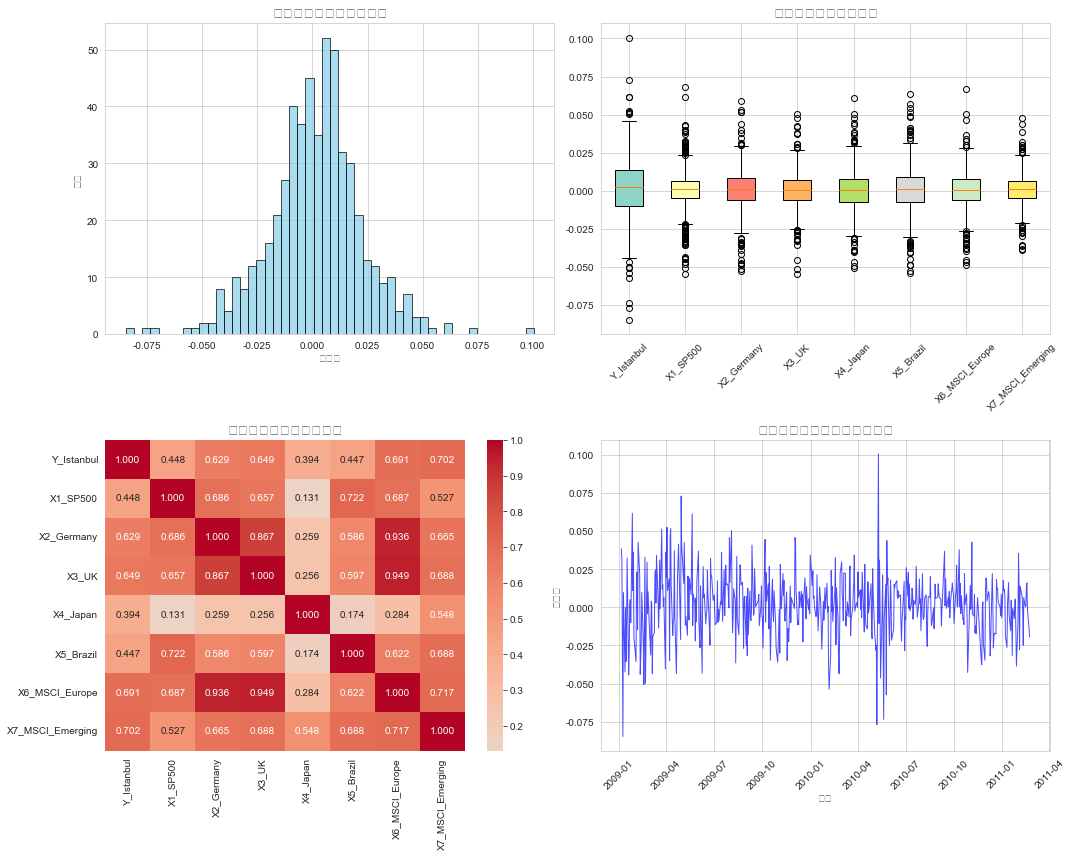

In [6]:
# 4. 探索性数据分析（通过可视化直观了解数据分布、关系和趋势）
print("\n4. 探索性数据分析")  # 打印标题，标识这是第4部分
print("-" * 40)  # 打印40个减号作为分隔线


# 4.1 基本统计可视化（通过图形展示数据的核心特征）
# 创建一个2行2列的子图布局，设置整个图形大小为15x12英寸
# fig：整个画布对象；axes：子图数组（2行2列的矩阵）
fig, axes = plt.subplots(2, 2, figsize=(15, 12))


# 第一个子图：目标变量（伊斯坦布尔指数）的分布直方图
# axes[0,0]：访问第1行第1列的子图
# hist()：绘制直方图
# df_clean['Y_Istanbul']：目标变量数据
# bins=50：将数据分成50个区间（柱子）
# alpha=0.7：设置透明度（0-1，值越小越透明）
# color='skyblue'：柱子填充色为天蓝色
# edgecolor='black'：柱子边缘色为黑色
axes[0,0].hist(df_clean['Y_Istanbul'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].set_title("伊斯坦布尔指数收益分布", fontsize=14, fontweight='bold')  # 设置标题，字体大小14，加粗
axes[0,0].set_xlabel("日收益")  # 设置x轴标签
axes[0,0].set_ylabel("频数")    # 设置y轴标签


# 第二个子图：各指数收益的箱线图（用于比较分布和异常值）
# 筛选出数据中实际存在的数值列（避免列名不存在的错误）
available_cols = [col for col in numeric_columns if col in df_clean.columns]
# 准备箱线图数据：将每个列的数据提取为列表
box_data = [df_clean[col] for col in available_cols]
# 设置每个箱线图的位置（从1开始的连续整数）
positions = range(1, len(available_cols) + 1)

# 绘制箱线图，patch_artist=True表示允许填充颜色
box_plot = axes[0,1].boxplot(box_data, positions=positions, patch_artist=True)
# 生成一组渐变色（使用Set3色系，数量与列数一致）
colors = plt.cm.Set3(np.linspace(0, 1, len(available_cols)))
# 给每个箱子填充不同颜色
for patch, color in zip(box_plot['boxes'], colors):
    patch.set_facecolor(color)

axes[0,1].set_title("各指数收益分布箱线图", fontsize=14, fontweight='bold')  # 设置标题
axes[0,1].set_xticks(positions)  # 设置x轴刻度位置
# 设置x轴刻度标签为列名，旋转45度避免重叠
axes[0,1].set_xticklabels(available_cols, rotation=45)


# 第三个子图：各指数收益的相关性热力图（展示变量间的相关程度）
# 计算数值列之间的相关系数矩阵（默认是皮尔逊相关系数）
corr_matrix = df_clean[available_cols].corr()
# 绘制热力图
# annot=True：在热力图上显示相关系数值
# cmap='coolwarm'：使用冷暖色调（红色正相关，蓝色负相关）
# center=0：以0为中心区分正负相关
# ax=axes[1,0]：指定在第2行第1列的子图绘制
# fmt='.3f'：系数保留3位小数
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=axes[1,0], fmt='.3f')
axes[1,0].set_title("各指数收益相关性热力图", fontsize=14, fontweight='bold')  # 设置标题


# 第四个子图：伊斯坦布尔指数收益的时间序列图（展示随时间的变化趋势）
# 绘制折线图：x轴为日期，y轴为伊斯坦布尔指数收益
axes[1,1].plot(df_clean['Date'], df_clean['Y_Istanbul'], alpha=0.7, linewidth=1, color='blue')
axes[1,1].set_title("伊斯坦布尔指数收益时间序列", fontsize=14, fontweight='bold')  # 设置标题
axes[1,1].set_xlabel("日期")  # 设置x轴标签
axes[1,1].set_ylabel("日收益")  # 设置y轴标签
axes[1,1].tick_params(axis='x', rotation=45)  # x轴标签旋转45度，避免重叠


# 自动调整子图之间的间距，避免标签重叠
plt.tight_layout()
# 显示图形
plt.show()

代码功能说明：
这部分是探索性数据分析（EDA）的核心可视化环节，通过 4 种不同图形从多个维度理解数据：
直方图：展示目标变量（伊斯坦布尔指数）的分布形态（是否正态、集中趋势等）
箱线图：比较所有指数的收益分布，快速识别异常值和数据离散程度
热力图：通过相关系数矩阵，直观展示各指数之间的相关性强弱（正相关 / 负相关）
时间序列图：观察伊斯坦布尔指数随时间的变化趋势（是否有周期性、趋势性等）
这些图形能帮助分析者快速发现数据规律（如哪些指数与目标指数相关性高、数据分布是否存在偏态等），为后续建模（如选择特征变量）提供重要依据。

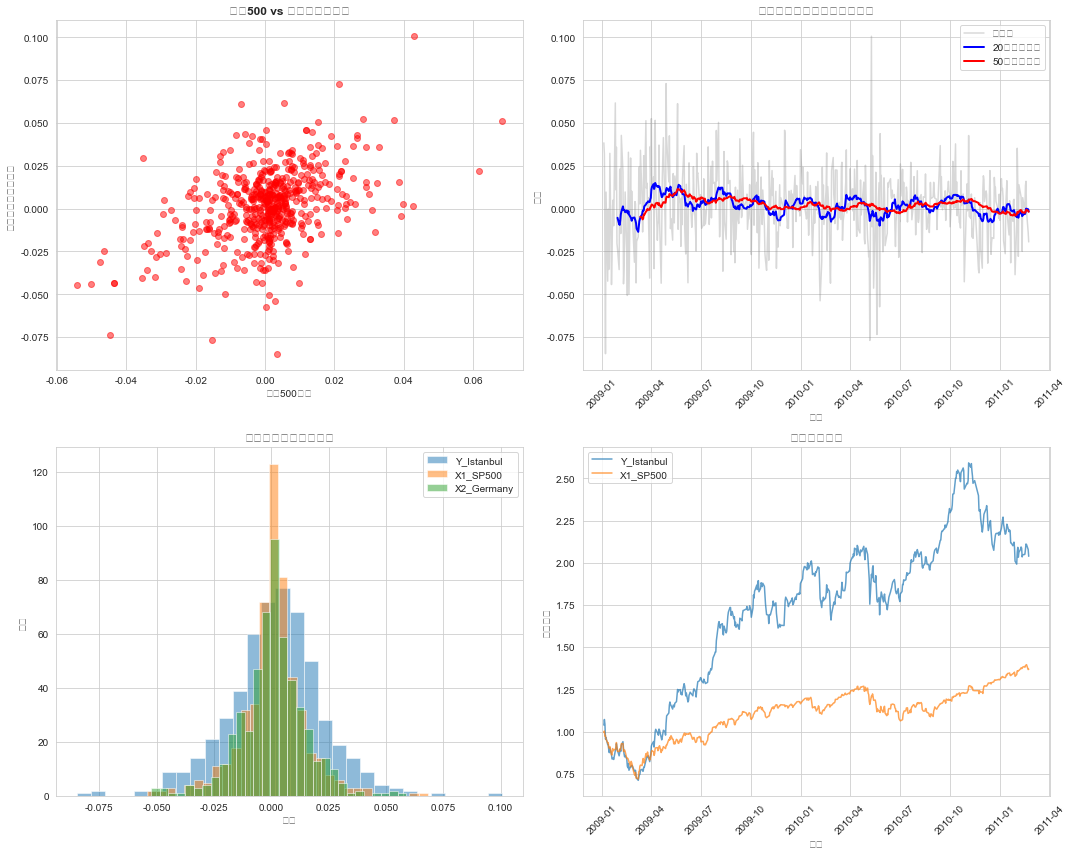

In [7]:
# 4.2 深入分析可视化（更细致的图形分析，挖掘数据深层特征）
# 创建2行2列的子图布局，画布大小15x12英寸
fig, axes = plt.subplots(2, 2, figsize=(15, 12))


# 第一个子图：标普500指数与伊斯坦布尔指数的散点图（分析两者线性关系）
# 先判断标普500列是否存在（避免报错）
if 'X1_SP500' in df_clean.columns:
    # 绘制散点图：x轴为标普500收益，y轴为伊斯坦布尔指数收益
    # alpha=0.5：点的透明度（避免点重叠时看不清），color='red'：点的颜色为红色
    axes[0,0].scatter(df_clean['X1_SP500'], df_clean['Y_Istanbul'], alpha=0.5, color='red')
    axes[0,0].set_xlabel('标普500收益')  # x轴标签
    axes[0,0].set_ylabel('伊斯坦布尔指数收益')  # y轴标签
    axes[0,0].set_title('标普500 vs 伊斯坦布尔指数', fontweight='bold')  # 标题，加粗


# 计算移动平均值（用于平滑短期波动，观察长期趋势）
# rolling(window=20).mean()：计算20天窗口期的移动平均值（短期趋势）
df_clean['Y_MA20'] = df_clean['Y_Istanbul'].rolling(window=20).mean()
# rolling(window=50).mean()：计算50天窗口期的移动平均值（中长期趋势）
df_clean['Y_MA50'] = df_clean['Y_Istanbul'].rolling(window=50).mean()

# 第二个子图：伊斯坦布尔指数的移动平均趋势图
# 绘制原始日收益曲线：alpha=0.3（淡灰色），作为背景参考
axes[0,1].plot(df_clean['Date'], df_clean['Y_Istanbul'], alpha=0.3, label='日收益', color='gray')
# 绘制20日移动平均线：蓝色，线宽2，标签为"20日移动平均"
axes[0,1].plot(df_clean['Date'], df_clean['Y_MA20'], label='20日移动平均', linewidth=2, color='blue')
# 绘制50日移动平均线：红色，线宽2，标签为"50日移动平均"
axes[0,1].plot(df_clean['Date'], df_clean['Y_MA50'], label='50日移动平均', linewidth=2, color='red')
axes[0,1].set_title('伊斯坦布尔指数移动平均趋势', fontweight='bold')  # 标题
axes[0,1].set_xlabel('日期')  # x轴标签
axes[0,1].set_ylabel('收益')  # y轴标签
axes[0,1].legend()  # 显示图例（区分不同曲线）
axes[0,1].tick_params(axis='x', rotation=45)  # x轴标签旋转45度，避免重叠


# 第三个子图：主要指数收益分布的直方图比较（观察分布差异）
# 只取前3个指数进行比较（避免图形太拥挤）
for col in available_cols[:3]:
    # 绘制每个指数的直方图：30个区间，透明度0.5，添加标签
    axes[1,0].hist(df_clean[col], bins=30, alpha=0.5, label=col)
axes[1,0].set_title('主要指数收益分布比较', fontweight='bold')  # 标题
axes[1,0].set_xlabel('收益')  # x轴标签
axes[1,0].set_ylabel('频数')  # y轴标签
axes[1,0].legend()  # 显示图例（区分不同指数）


# 计算累积收益（反映长期投资回报）
# (1 + 日收益).cumprod()：每日收益加1后连乘，得到累积收益（复利效果）
cumulative_returns = (1 + df_clean[available_cols]).cumprod()

# 第四个子图：累积收益趋势图（比较不同指数的长期表现）
# 只取前2个指数进行比较（避免曲线过多导致混乱）
for col in available_cols[:2]:
    # 绘制累积收益曲线：透明度0.7，添加标签
    axes[1,1].plot(df_clean['Date'], cumulative_returns[col], label=col, alpha=0.7)
axes[1,1].set_title('累积收益趋势', fontweight='bold')  # 标题
axes[1,1].set_xlabel('日期')  # x轴标签
axes[1,1].set_ylabel('累积收益')  # y轴标签（值为1表示不赚不亏，大于1表示盈利）
axes[1,1].legend()  # 显示图例
axes[1,1].tick_params(axis='x', rotation=45)  # x轴标签旋转45度


# 自动调整子图间距，避免标签重叠
plt.tight_layout()
# 显示图形
plt.show()

代码功能说明：
这部分是探索性数据分析的深入可视化，通过 4 种针对性图形挖掘更具体的规律：
散点图：聚焦标普 500 与伊斯坦布尔指数的关系，直观判断两者是否存在线性相关性（点的分布是否接近直线）。
移动平均线图：通过 20 日（短期）和 50 日（中长期）均线，平滑日收益的短期波动，更清晰地观察伊斯坦布尔指数的趋势方向（如均线向上 / 向下、短期均线与长期均线的交叉关系）。
直方图比较：将多个指数的收益分布绘制在同一图中，便于对比它们的集中趋势（均值 / 中位数位置）、离散程度（分布宽窄）和形态（是否对称）。
累积收益图：基于复利计算，展示不同指数随时间的累积回报，直观反映长期投资表现（如哪个指数增长更快、波动更小）。
这些图形帮助分析者从相关性、趋势性、分布差异和长期表现等维度深入理解数据，为后续建模（如特征选择、模型设计）提供更具体的依据。

In [8]:
# 5. 回归预测分析（用其他指数预测伊斯坦布尔指数，分析影响因素）
print("\n5. 回归预测分析")  # 打印标题，标识这是第5部分
print("-" * 40)  # 打印40个减号作为分隔线


# 准备建模数据（区分特征变量和目标变量）
# 从可用的数值列中筛选出特征列：排除目标变量Y_Istanbul，其余作为输入特征
X_columns = [col for col in available_cols if col != 'Y_Istanbul']


# 检查是否有足够的变量进行建模
if X_columns and 'Y_Istanbul' in df_clean.columns:  # 确保有特征列和目标列
    # 特征变量X：用于预测的其他指数（如标普500、德国指数等）
    X = df_clean[X_columns]
    # 目标变量y：需要预测的伊斯坦布尔指数
    y = df_clean['Y_Istanbul']
    
    
    # 数据标准化（让不同量级的特征具有可比性，提升模型稳定性）
    scaler = StandardScaler()  # 初始化标准化工具（将数据转换为均值0、标准差1的分布）
    X_scaled = scaler.fit_transform(X)  # 对特征数据进行标准化处理
    
    
    # 分割训练集和测试集（评估模型的泛化能力）
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled,  # 标准化后的特征数据
        y,         # 目标变量
        test_size=0.33,  # 测试集占比33%（训练集占67%）
        random_state=42  # 随机种子（保证每次运行分割结果一致，便于复现）
    )
    
    
    # 训练线性回归模型
    model = LinearRegression()  # 初始化线性回归模型
    model.fit(X_train, y_train)  # 用训练集数据训练模型（学习特征与目标的关系）
    
    
    # 模型预测与性能评估
    y_pred = model.predict(X_test)  # 用训练好的模型预测测试集的目标值
    
    # 计算评估指标（衡量预测效果）
    mse = mean_squared_error(y_test, y_pred)  # 均方误差：预测值与真实值差的平方的均值
    rmse = np.sqrt(mse)  # 均方根误差：MSE的平方根（与原始数据单位一致）
    mae = mean_absolute_error(y_test, y_pred)  # 平均绝对误差：预测值与真实值差的绝对值的均值
    r2 = r2_score(y_test, y_pred)  # 决定系数：衡量模型对数据的解释能力（范围0-1，越接近1越好）
    
    # 打印评估结果
    print("回归模型性能:")
    print(f"均方误差 (MSE): {mse:.6f}")  # 保留6位小数
    print(f"均方根误差 (RMSE): {rmse:.6f}")
    print(f"平均绝对误差 (MAE): {mae:.6f}")
    print(f"决定系数 (R²): {r2:.4f}")  # 保留4位小数
    
    
    # 回归系数分析（判断各特征对目标的影响大小和方向）
    coefficients = pd.DataFrame({
        '特征': X_columns,  # 特征名称
        '系数': model.coef_,  # 回归系数（正值表示正影响，负值表示负影响）
        '系数绝对值': np.abs(model.coef_)  # 系数的绝对值（表示影响强度）
    }).sort_values('系数绝对值', ascending=False)  # 按影响强度从大到小排序
    
    print("\n回归系数:")
    display(coefficients)  # 展示系数表格
    print(f"截距: {model.intercept_:.6f}")  # 打印截距（回归方程中的常数项）
    
else:
    # 如果缺少特征列或目标列，提示无法建模
    print("无法进行回归分析：缺少必要的变量")


5. 回归预测分析
----------------------------------------
回归模型性能:
均方误差 (MSE): 0.000207
均方根误差 (RMSE): 0.014398
平均绝对误差 (MAE): 0.010912
决定系数 (R²): 0.6148

回归系数:


,特征,系数,系数绝对值
5,X6_MSCI_Europe,0.017117,0.017117
6,X7_MSCI_Emerging,0.010589,0.010589
1,X2_Germany,-0.005519,0.005519
2,X3_UK,-0.004063,0.004063
4,X5_Brazil,-0.003201,0.003201
0,X1_SP500,0.000620,0.000620
3,X4_Japan,-0.000167,0.000167


截距: 0.001483


代码功能说明：
这部分是预测建模核心环节，通过线性回归模型分析其他指数对伊斯坦布尔指数的影响，具体做了：
数据准备：区分特征变量（其他指数）和目标变量（伊斯坦布尔指数）。
标准化：消除不同指数的量级差异（如有的指数波动大、有的波动小），让模型更可靠。
数据分割：将数据分为训练集（用于建模）和测试集（用于评估模型是否能推广到新数据）。
模型训练：用线性回归学习特征与目标的关系（得到回归方程：y = 截距 + 系数 1×X1 + 系数 2×X2 + ...）。
性能评估：通过 MSE、RMSE、MAE（衡量预测误差大小）和 R²（衡量模型解释力）评估效果。
系数分析：通过回归系数判断各指数的影响（系数正负表示方向，绝对值表示影响强度）。
通过这些步骤，能明确哪些指数对伊斯坦布尔指数影响最大，以及模型的预测能力如何。


6. 残差分析
----------------------------------------


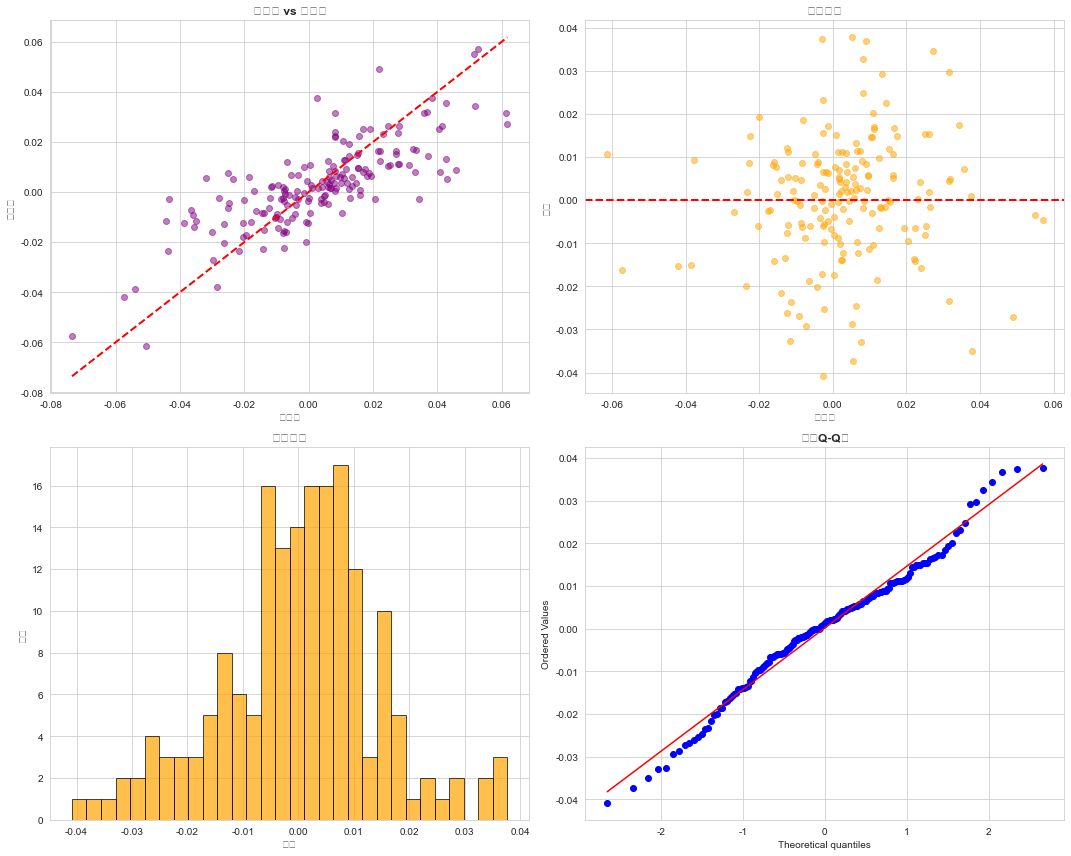

In [9]:
# 6. 残差分析可视化（通过残差评估模型拟合效果，检验回归假设）
print("\n6. 残差分析")  # 打印标题，标识这是第6部分
print("-" * 40)  # 打印40个减号作为分隔线


# 检查是否存在预测结果y_pred（确保前面的回归分析已成功运行）
if 'y_pred' in locals():  # locals()返回当前局部变量字典，判断'y_pred'是否在其中
    # 计算残差：残差 = 实际值 - 预测值（反映模型未解释的误差）
    residuals = y_test - y_pred
    
    # 创建2行2列的子图布局，画布大小15x12英寸
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    
    # 第一个子图：预测值 vs 实际值散点图（判断整体拟合效果）
    # 绘制散点图：x轴为实际值，y轴为预测值，紫色点，透明度0.5
    axes[0,0].scatter(y_test, y_pred, alpha=0.5, color='purple')
    # 绘制参考线：从实际值最小值到最大值的对角线（y=x）
    # 若点都接近这条线，说明预测值与实际值接近，拟合效果好
    axes[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
    axes[0,0].set_xlabel('实际值')  # x轴标签
    axes[0,0].set_ylabel('预测值')  # y轴标签
    axes[0,0].set_title('预测值 vs 实际值', fontweight='bold')  # 标题，加粗
    
    
    # 第二个子图：残差图（判断残差是否随机分布，检验模型假设）
    # 绘制散点图：x轴为预测值，y轴为残差，橙色点，透明度0.5
    axes[0,1].scatter(y_pred, residuals, alpha=0.5, color='orange')
    # 绘制水平线y=0（残差的理论均值）
    axes[0,1].axhline(y=0, color='r', linestyle='--', linewidth=2)
    # 理想状态：残差随机分布在0线附近，无明显趋势（说明模型无遗漏的特征）
    axes[0,1].set_xlabel('预测值')  # x轴标签
    axes[0,1].set_ylabel('残差')    # y轴标签
    axes[0,1].set_title('残差分析', fontweight='bold')  # 标题
    
    
    # 第三个子图：残差分布直方图（检验残差是否符合正态分布）
    # 绘制残差的直方图：30个区间，橙色，边缘黑色，透明度0.7
    axes[1,0].hist(residuals, bins=30, alpha=0.7, color='orange', edgecolor='black')
    # 线性回归假设残差服从正态分布（分布越接近对称钟形，假设越成立）
    axes[1,0].set_xlabel('残差')    # x轴标签
    axes[1,0].set_ylabel('频数')    # y轴标签
    axes[1,0].set_title('残差分布', fontweight='bold')  # 标题
    
    
    # 第四个子图：残差Q-Q图（更严格地检验正态性）
    from scipy import stats  # 导入scipy的统计模块
    # 绘制Q-Q图：比较残差分布与理论正态分布的分位数
    # 若点接近对角线，说明残差近似正态分布
    stats.probplot(residuals, dist="norm", plot=axes[1,1])
    axes[1,1].set_title('残差Q-Q图', fontweight='bold')  # 标题
    
    
    # 自动调整子图间距，避免标签重叠
    plt.tight_layout()
    # 显示图形
    plt.show()

代码功能说明：
残差分析是回归模型评估的关键环节，通过 4 种图形从不同角度检验模型质量：
预测值 vs 实际值图：判断预测值与真实值的整体吻合程度。点越接近对角线（y=x），说明预测越准确。
残差图：检验残差是否具有随机性。若残差在 0 线附近随机分布，无明显趋势（如递增 / 递减），说明模型未遗漏重要特征；若有明显趋势，可能需要改进模型。
残差分布直方图：直观观察残差是否近似正态分布（线性回归的核心假设之一）。分布越对称、接近钟形，假设越成立。
残差 Q-Q 图：通过分位数对比，更精确地检验残差的正态性。点越接近对角线，正态性越好。
这些图形帮助分析者判断模型是否满足假设、是否存在系统性误差，为模型优化提供方向（如是否需要添加特征、转换变量等）。

In [10]:
# 7. 最终报告和结果保存（汇总分析结果，生成报告并保存清洗后的数据）
print("\n7. 分析报告总结")  # 打印标题，标识这是第7部分（最终总结环节）
print("-" * 40)  # 打印40个减号作为分隔线，美化输出格式


# 1. 计算并展示关键统计指标（概括各指数的核心数据特征）
print("关键统计指标:")
# agg(['mean', 'std', 'min', 'max']): 对每个指数列计算4个核心统计量
# - mean: 均值（反映收益平均水平）
# - std: 标准差（反映收益波动大小，值越大风险越高）
# - min: 最小值（历史最低收益）
# - max: 最大值（历史最高收益）
# round(6): 结果保留6位小数，避免数值过长
stats_summary = df_clean[available_cols].agg(['mean', 'std', 'min', 'max']).round(6)
display(stats_summary)  # 友好展示统计结果表格


# 2. 展示与伊斯坦布尔指数的相关性分析（突出影响最大的指数）
# 先判断之前计算的相关系数矩阵是否存在（避免报错）
if 'corr_matrix' in locals():
    print(f"\n与伊斯坦布尔指数相关性分析:")
    # 提取相关系数矩阵中"伊斯坦布尔指数（Y_Istanbul）"与其他指数的相关性
    # drop('Y_Istanbul'): 排除自身与自身的相关性（恒为1，无意义）
    istanbul_corr = corr_matrix['Y_Istanbul'].drop('Y_Istanbul')
    # 按相关性绝对值从大到小排序，取前3个（找出影响最大的指数）
    top_correlations = istanbul_corr.abs().sort_values(ascending=False).head(3)
    
    print("相关性最高的三个指数:")
    # 遍历前3个高相关性指数，输出排名、指数名称和具体相关系数
    for idx, (index_name, corr_val) in enumerate(top_correlations.items(), 1):
        actual_corr = istanbul_corr[index_name]  # 获取原始相关系数（含正负，反映方向）
        print(f"{idx}. {index_name}: {actual_corr:.4f}")  # 保留4位小数，格式更整洁


# 3. 保存清洗后的数据（便于后续复用或分享）
# to_csv(): 将DataFrame保存为CSV文件
# 'cleaned_stock_data.csv': 保存的文件名（意为"清洗后的股票数据"）
# index=False: 不保存行索引（避免冗余）
# encoding='utf-8-sig': 用UTF-8编码保存，确保中文（若有）正常显示
df_clean.to_csv('../data/cleaned_stock_data.csv', index=False, encoding='utf-8-sig')


# 4. 打印完整的分析总结（用格式化字符串整合所有关键信息）
print(f"""
分析总结:
1. 数据概况:
   - 分析期间: {df_clean['Date'].min().strftime('%Y-%m-%d')} 至 {df_clean['Date'].max().strftime('%Y-%m-%d')}
     # 取日期列的最小值（最早日期）和最大值（最晚日期），用strftime转为"年-月-日"格式
   - 总记录数: {len(df_clean)}  # len(df_clean)获取数据总行数（即观测次数）
   - 分析变量数: {len(available_cols)}  # 获取参与分析的指数列数量

2. 主要发现:
   - 伊斯坦布尔指数平均日收益: {df_clean['Y_Istanbul'].mean():.6f}  # 均值，反映平均收益水平
   - 收益波动性(标准差): {df_clean['Y_Istanbul'].std():.6f}  # 标准差，反映风险高低
   - 模型预测精度(R²): {r2 if 'r2' in locals() else 'N/A'}  # 若存在R²则显示，否则标为"未获取"

3. 处理完成:
   - 清洗后的数据已保存为: cleaned_stock_data.csv  # 提示文件保存路径和名称
   - 包含完整的分析结果和可视化  # 说明文件内容价值
""")

# 打印分析完成的提示，用✅符号增强视觉反馈
print("\n✅ 数据分析完成!")


7. 分析报告总结
----------------------------------------
关键统计指标:


,Y_Istanbul,X1_SP500,X2_Germany,X3_UK,X4_Japan,X5_Brazil,X6_MSCI_Europe,X7_MSCI_Emerging
mean,0.001552,0.000685,0.000746,0.000529,0.000348,0.000998,0.000475,0.000936
std,0.021122,0.014093,0.014557,0.012655,0.014850,0.015749,0.012990,0.010501
min,-0.084716,-0.054262,-0.052331,-0.054816,-0.050448,-0.053849,-0.048817,-0.038564
max,0.100621,0.068366,0.058951,0.050323,0.061229,0.063792,0.067042,0.047805



与伊斯坦布尔指数相关性分析:
相关性最高的三个指数:
1. X7_MSCI_Emerging: 0.7020
2. X6_MSCI_Europe: 0.6908
3. X3_UK: 0.6486

分析总结:
1. 数据概况:
   - 分析期间: 2009-01-05 至 2011-02-22
     # 取日期列的最小值（最早日期）和最大值（最晚日期），用strftime转为"年-月-日"格式
   - 总记录数: 536  # len(df_clean)获取数据总行数（即观测次数）
   - 分析变量数: 8  # 获取参与分析的指数列数量

2. 主要发现:
   - 伊斯坦布尔指数平均日收益: 0.001552  # 均值，反映平均收益水平
   - 收益波动性(标准差): 0.021122  # 标准差，反映风险高低
   - 模型预测精度(R²): 0.6147912105688031  # 若存在R²则显示，否则标为"未获取"

3. 处理完成:
   - 清洗后的数据已保存为: cleaned_stock_data.csv  # 提示文件保存路径和名称
   - 包含完整的分析结果和可视化  # 说明文件内容价值


✅ 数据分析完成!


代码功能说明：
这部分是整个数据分析流程的收尾环节，核心作用是「汇总成果 + 固化数据」，具体做了三件关键事：
提炼核心统计量：用均值、标准差等指标概括各指数的收益水平和风险，让结果更直观；
聚焦关键关联：筛选与伊斯坦布尔指数相关性最高的指数，突出分析的核心发现；
保存清洗数据：将预处理后的高质量数据存为 CSV 文件，避免后续重复清洗，方便复用；
生成总结报告：用自然语言整合数据时间范围、样本量、核心结论等信息，让非技术人员也能快速理解分析结果。
通过这一步，整个分析从 "过程" 转化为 "可复用的结果"，既完成了报告输出，也为后续深入分析或应用（如导入其他工具）打下基础。